In [1]:
import pandas as pd
processed_df = pd.read_csv(r'D:\sprints project\processed_data.csv')
processed_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


### 1. Apply PCA to reduce dimensionality

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = processed_df.drop(columns='num')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

### 2. Determine optimal number of components using explained variance ratio

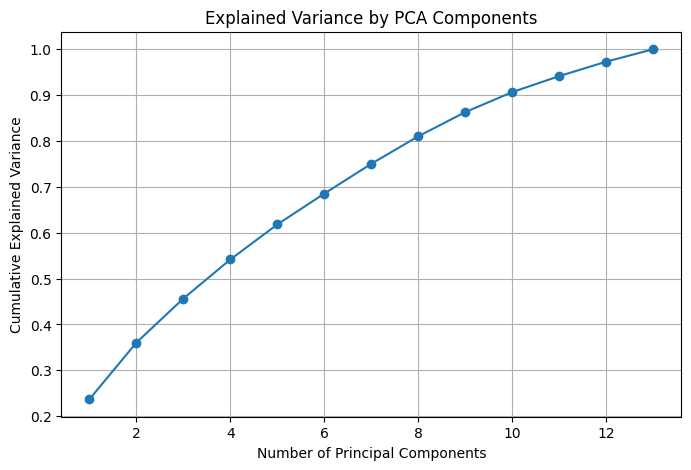

In [3]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()

### 3. Visualize PCA results (scatter plot)

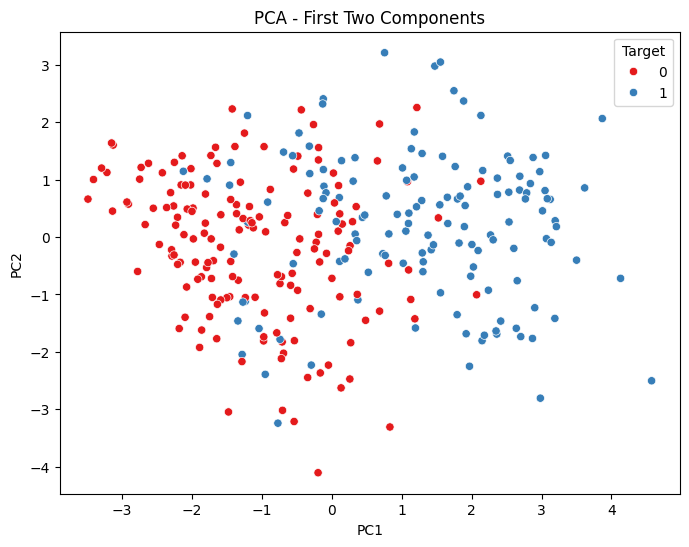

In [4]:
pca_10 = PCA(n_components=10)
X_pca_10 = pca_10.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_10, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10'])
pca_df['Target'] = processed_df['num']

# Scatter plot
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2',hue='Target', palette='Set1')
plt.title("PCA - First Two Components")
plt.show()

In [5]:
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Target
0,1.130664,-1.087655,3.164263,2.293052,0.023175,0.578814,0.664854,-0.536787,-1.495392,-0.499485,0
1,3.190926,-1.417885,-0.533715,-0.857970,-0.006289,0.745347,-0.259063,1.069777,0.342524,1.431509,1
2,3.124339,0.657008,-0.285134,-0.626641,0.152793,1.130179,-0.324995,0.209299,0.043205,0.462304,1
3,-0.484339,1.410972,0.397806,2.832741,0.721309,-0.388361,-0.522221,-2.153525,0.760079,0.228379,0
4,-2.284542,-0.330033,-0.072260,1.209318,0.770835,0.625587,0.379567,0.014736,1.050381,0.628110,0


In [6]:
pca_df.to_csv("D:\sprints project\pca_data.csv", index=False)